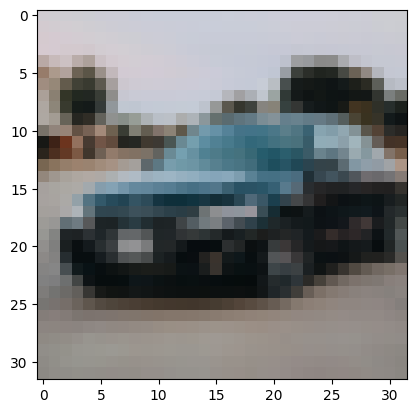

In [2]:
# Ваш код для необходимых импортов и чтения изображения
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms import Resize
image = Image.open("data/car.png")

resized_image = Resize((32, 32))(image)

# визуализация результата
plt.imshow(resized_image)

In [ ]:
from torchvision.transforms.v2 import Normalize
from torchvision.transforms.functional import to_tensor
from PIL import Image


image = Image.open("data/car.png")
# Нормализация не работает с PIL, только с pyTorch тензорами
image_tensor = to_tensor(image)

# # Первый способ, однако загруженное с помощью PIL изображение 
# # уже имеет значения в интервале [0,1]
# # image_tensor /= 255  

# Второй способ
# Вычесть примерное среднее (0.5 для интервала [0, 1]),
# Примерное std - так же 0.5
normalize = Normalize(mean=[0.5, 0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5, 0.5])
normalized_image = normalize(image_tensor)
normalized_image

# # # Третий способ
# # # Использовать среднее и std из конкретного датасета
# # # В этом примере - из датасета ImageNet
# # normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# # normalized_image = normalize(image_tensor)

tensor([[[ 0.6078,  0.6078,  0.6078,  ...,  0.6000,  0.6000,  0.6000],
         [ 0.6078,  0.6078,  0.6078,  ...,  0.6000,  0.6000,  0.6000],
         [ 0.6235,  0.6235,  0.6235,  ...,  0.6000,  0.6078,  0.6000],
         ...,
         [ 0.0039,  0.0039,  0.0275,  ...,  0.1059,  0.1216,  0.1137],
         [ 0.0431,  0.0431,  0.0353,  ...,  0.1137,  0.1059,  0.0745],
         [ 0.0510,  0.0510,  0.0745,  ...,  0.1451,  0.0980,  0.1137]],

        [[ 0.6000,  0.6000,  0.6000,  ...,  0.6157,  0.6078,  0.6078],
         [ 0.6000,  0.6000,  0.6000,  ...,  0.6157,  0.6078,  0.6078],
         [ 0.6078,  0.6078,  0.6078,  ...,  0.6000,  0.6000,  0.5922],
         ...,
         [-0.0196, -0.0196,  0.0039,  ...,  0.0667,  0.0745,  0.0667],
         [ 0.0196,  0.0196,  0.0118,  ...,  0.0745,  0.0667,  0.0275],
         [ 0.0196,  0.0196,  0.0431,  ...,  0.1059,  0.0588,  0.0745]],

        [[ 0.6314,  0.6314,  0.6314,  ...,  0.6392,  0.6314,  0.6314],
         [ 0.6314,  0.6314,  0.6314,  ...,  0

В примере аугментация была очень агрессивной — почти все примеры в датасете были отражены и по обеим осям, и повёрнуты на значительный градус. Кроме того, для чёрно-белых изображений кажется избыточным изменение оттенка и контраста. Поэтому создайте новый пайплайн аугментации для FashionMNIST. Он должен состоять из:
1. Отражений по вертикали и горизонтали, оба с вероятностью срабатывания 0.3.
1. Поворотов в интервале [-10, 10] градусов.

Готовый пайплайн поместите в переменную transforms.

Выполните задание локально, а затем сверьтесь с ожидаемым выводом и авторским решением. 

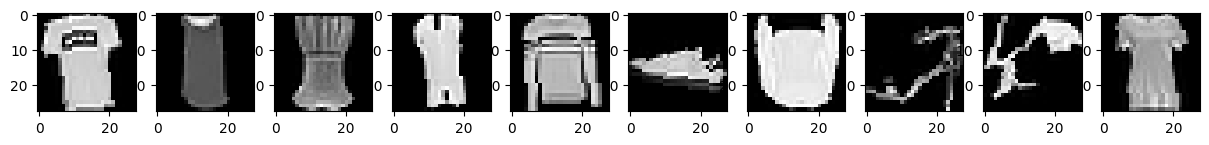

In [16]:
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose
from torchvision.datasets import FashionMNIST
from matplotlib import pyplot as plt

transforms = Compose([
    RandomHorizontalFlip(p=0.3),
    RandomVerticalFlip(p=0.3),
    # RandomPhotometricDistort(p=0.5,
    #                          contrast=[0.8, 1.2],
    #                          hue=[-0.1, 0.1]),
    RandomRotation([-10, 10])
])

dataset = FashionMNIST(root ='data/', download=True, transform=transforms)

# Визуализация
fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = dataset[index]
    plt.subplot(1, 10, index)
    plt.imshow(image, cmap='gray')

## Задание
Используя загруженную модель EfficientNet_b0 (младшая версия EfficientNet), обученную на ImageNet, заморозьте веса всей модели, кроме последнего полносвязного слоя. Для этого:
1. Заморозьте веса всей модели.
2. Разморозьте последний полносвязный слой.

Выполните задание локально, а затем сверьтесь с ожидаемым выводом и авторским решением. 

In [49]:
import torchvision
from torchsummary import summary
from torchvision.models import efficientnet_b0

# Модель для заморозки
model = efficientnet_b0(weights='IMAGENET1K_V1')

# # Ваш код для заморозки всей модели
for param in model.parameters():
    param.requires_grad = False

# # Ваш код для разморозки последнего полносвязного слоя
for param in model.classifier.parameters():
    param.requires_grad = True

# Проверка
summary(model, input_size=(3, 224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1